In [ ]:
# Telecom Customer Churn Analysis

# This project analyzes customer churn behavior using Python and identifies key drivers such as customer service calls, 
# usage patterns, and international plan subscriptions.

# Problem Statement
# Customer churn is a major concern for telecom companies. 
# This analysis explores customer usage, service calls, plan details, and regional patterns to identify possible churn drivers.


In [2]:
# Import required libraries and load the telecom churn dataset.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
train_df = pd.read_csv(r"churn-bigml-80.csv")
test_df = pd.read_csv(r"churn-bigml-20.csv")

## Initial Data Exploration
train_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [21]:
test_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [4]:
train_df.shape

(2666, 20)

In [5]:
test_df.shape

(667, 20)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

In [8]:
train_df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

In [9]:
test_df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

In [4]:
# Overall churn rate
train_df['Churn'].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

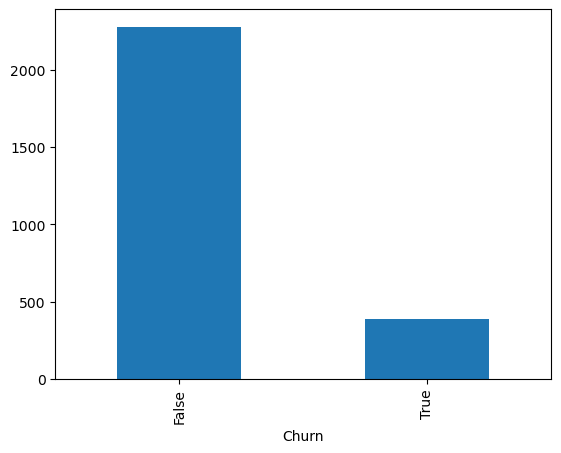

In [10]:
train_df['Churn'].value_counts().plot(kind='bar')
plt.show()

In [12]:
# Churn by International Plan
train_df.groupby('International plan')['Churn'].value_counts(normalize=True)

International plan  Churn
No                  False    0.887312
                    True     0.112688
Yes                 False    0.562963
                    True     0.437037
Name: proportion, dtype: float64

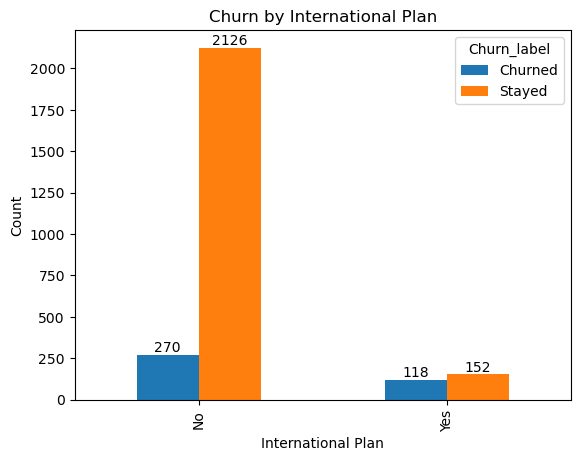

In [13]:
train_df['Churn_label'] = train_df['Churn'].map({True: "Churned", False: "Stayed"})
ax = train_df.groupby('International plan')['Churn_label'].value_counts().unstack().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn by International Plan")
plt.xlabel("International Plan")
plt.ylabel("Count")
plt.savefig("churn_by International plan.png")
plt.show()

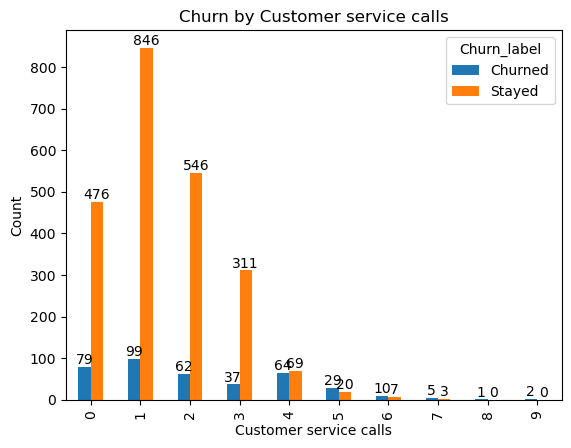

In [14]:
# Churn by Customer service calls
train_df['Churn_label'] = train_df['Churn'].map({True: "Churned", False: "Stayed"})
ax = train_df.groupby('Customer service calls')['Churn_label'].value_counts().unstack().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn by Customer service calls")
plt.xlabel("Customer service calls")
plt.ylabel("Count")
plt.savefig("churn_by Customer Service Calls.png")
plt.show()

In [17]:
print("Key Insights:")
print("1. Overall churn is ~14.5%")
print("2. Customers with international plan have ~43% churn")
print("3. Customers with 4+ service calls have very high churn")
print("4. Customers with BOTH international plan and high calls are highest risk")

Key Insights:
1. Overall churn is ~14.5%
2. Customers with international plan have ~43% churn
3. Customers with 4+ service calls have very high churn
4. Customers with BOTH international plan and high calls are highest risk


In [15]:
high_risk = train_df[
    (train_df['International plan'] == 'Yes') &
    (train_df['Customer service calls'] >= 4)
]
print("High Risk Customers:", len(high_risk))

High Risk Customers: 22


In [16]:
train_df.groupby('Voice mail plan')['Churn'].mean()

Voice mail plan
No     0.167098
Yes    0.088677
Name: Churn, dtype: float64

<Axes: xlabel='Customer service calls'>

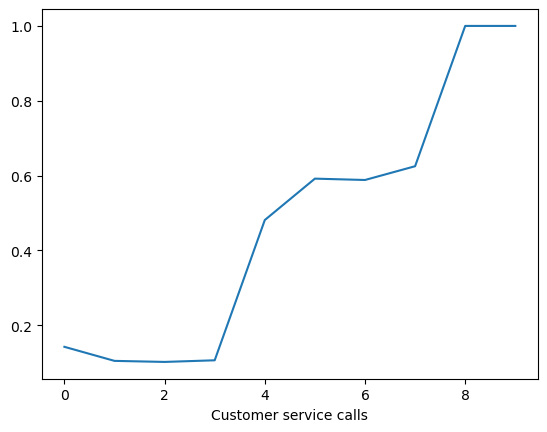

In [17]:
train_df.groupby('Customer service calls')['Churn'].mean().plot(kind='line')

In [19]:
# State-level churn analysis
train_df.groupby('State')['Churn'].mean().sort_values(ascending=False)

State
TX    0.290909
NJ    0.280000
AR    0.234043
MD    0.233333
MS    0.229167
SC    0.224490
ME    0.224490
MI    0.224138
PA    0.222222
NV    0.213115
NH    0.209302
WA    0.208333
CA    0.208333
KS    0.192308
MT    0.188679
CT    0.186441
MN    0.185714
NY    0.176471
GA    0.163265
NC    0.160714
DE    0.156863
MA    0.153846
OH    0.151515
KY    0.139535
OK    0.134615
UT    0.133333
FL    0.129630
SD    0.122449
TN    0.121951
WY    0.121212
CO    0.118644
OR    0.112903
IN    0.111111
DC    0.111111
AL    0.106061
VT    0.105263
MO    0.098039
ND    0.090909
NM    0.090909
ID    0.089286
NE    0.088889
IL    0.088889
LA    0.085714
WV    0.079545
IA    0.078947
AK    0.069767
AZ    0.066667
WI    0.065574
RI    0.062500
VA    0.059701
HI    0.045455
Name: Churn, dtype: float64

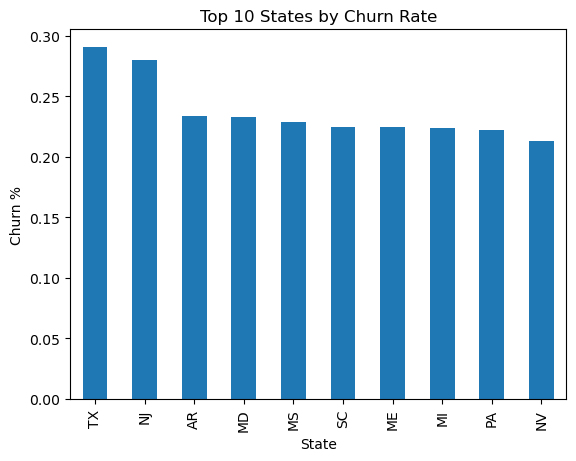

In [24]:
ax= train_df.groupby('State')['Churn'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Churn Rate")
plt.ylabel("Churn %")
plt.savefig("States by Churn Rate.png")
plt.show()

In [25]:
train_df.groupby(['State','Customer service calls'])['Churn'].mean()

State  Customer service calls
AK     0                         0.000000
       1                         0.062500
       2                         0.000000
       3                         0.000000
       4                         0.500000
                                   ...   
WY     1                         0.066667
       2                         0.090909
       3                         0.142857
       4                         0.000000
       5                         1.000000
Name: Churn, Length: 308, dtype: float64

In [26]:
# States have the most frustrated customers leaving
# Identify high-risk customers (4+ service calls)
# Analyze churn rate across states for these customers
train_df[train_df['Customer service calls'] >= 4].groupby('State')['Churn'].mean().sort_values(ascending=False)

State
MS    1.000000
UT    1.000000
TN    1.000000
SD    1.000000
PA    1.000000
NM    1.000000
MT    1.000000
AR    0.875000
NH    0.800000
ME    0.800000
WA    0.750000
NV    0.750000
MN    0.750000
MI    0.750000
NY    0.714286
LA    0.666667
AK    0.666667
IN    0.666667
KS    0.666667
WV    0.625000
AL    0.600000
TX    0.600000
NJ    0.600000
OR    0.600000
SC    0.571429
GA    0.500000
DC    0.500000
KY    0.500000
CA    0.500000
WI    0.500000
ID    0.500000
MA    0.500000
FL    0.500000
MD    0.444444
DE    0.400000
IA    0.400000
WY    0.400000
OH    0.333333
CT    0.333333
MO    0.333333
IL    0.333333
VT    0.285714
NC    0.250000
OK    0.200000
HI    0.200000
CO    0.142857
NE    0.000000
RI    0.000000
ND    0.000000
VA    0.000000
AZ    0.000000
Name: Churn, dtype: float64

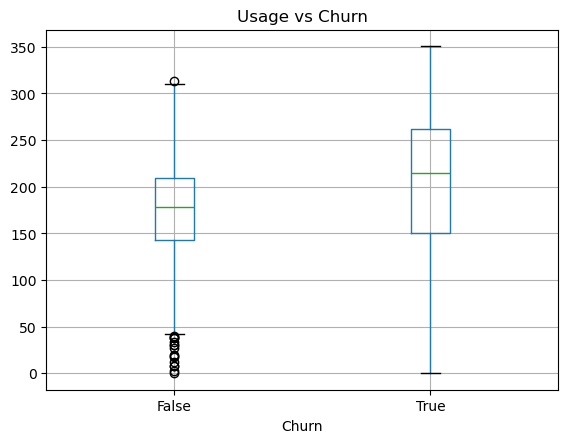

In [27]:
#Compare usage of: Stayed customers vs Churned customers
train_df.boxplot(column='Total day minutes', by='Churn')
import matplotlib.pyplot as plt
plt.title("Usage vs Churn")
plt.suptitle("")
plt.show()
# Churned customers generally have higher day usage than non-churned customers.
# This may suggest that heavy usage or related billing experience could be linked to churn.

In [28]:
# Churn analysis based on Total day charge
train_df.groupby('Churn')['Total day charge'].mean()

Churn
False    29.768266
True     34.881340
Name: Total day charge, dtype: float64

In [30]:
high_usage = train_df['Total day minutes'] > train_df['Total day minutes'].mean()
high_calls = train_df['Customer service calls'] >= 4

train_df['Segment'] = "Normal"

train_df.loc[high_usage & high_calls, 'Segment'] = "High Usage + High Complaints"
train_df.loc[high_usage & ~high_calls, 'Segment'] = "High Usage Only"
train_df.loc[~high_usage & high_calls, 'Segment'] = "High Complaints Only"
train_df.groupby('Segment')['Churn'].mean()

Segment
High Complaints Only            0.758621
High Usage + High Complaints    0.244681
High Usage Only                 0.167068
Normal                          0.056978
Name: Churn, dtype: float64

In [ ]:
# Customer complaints are the strongest driver of churn, more than usage.